In [1]:
import os

# Convert notes to Roman numerals
c2roman = {
	'Cb':	'bI',
	'C':	'I',
	'C#':	'#I',
	'Db':	'bII',
	'D':	'II',
	'D#':	'#II',
	'Eb':	'bIII',
	'E':	'III',
	'F':	'IV',
	'F#':	'#IV',
	'Gb':	'bV',
	'G':	'V',
	'G#':	'#V',
	'Ab':	'bVI',
	'A':	'VI',
	'A#':	'#VI',
	'Bb':	'bVII',
	'B':	'VII',
	'B#':	'#VII'
}

# Convert raw chord to tuple of (root, quality, inversion)
def parse_chord(raw_chord, ignore_inversion=False):
	if raw_chord[0] == '.':
		return ('.', None, None)
	chord, inversion = raw_chord.split('/')
	if len(chord) > 1 and chord[1] in ['b', '#']:
		root = chord[:2]
		quality = chord[2:]
	else:
		root = chord[0]
		quality = chord[1:]
	if quality == '':
		quality = 'maj'
	inversion = None if ignore_inversion else int(inversion)

	return (root, quality, inversion)

# Diaplsy chord in Roman numal notation
def display_chord(chord):
	root, quality, inversion = chord
	if inversion:
		return(c2roman[root] + quality + '/' + str(inversion))
	else:
		return(c2roman[root] + quality)

# Read chords form file
def read_chords(filename, ignore_inversion=False):
	if not os.path.exists(filename):
		print(f"File {filename} does not exist.")
		return []


	with open(filename, 'r') as file:
		if ignore_inversion:
			chords = [parse_chord(c, ignore_inversion=True) for c in file.read().splitlines()]
		else:
			chords = [parse_chord(c, ignore_inversion) for c in file.read().splitlines()]
	return chords

In [2]:
c = parse_chord('G7sus4/0')
display_chord(c)

'V7sus4'

# Treat inverted chords differently

In [3]:
from collections import Counter
import math

def calculate_entropy(chords):
	counts = Counter(chords)
	total = len(chords)
	entropy = -sum((count/total) * math.log2(count/total) for count in counts.values())
	return entropy

bach_chords = read_chords(os.path.join('bach', 'wtc1-prelude1.txt'))
beethoven2_chords = read_chords(os.path.join('beethoven', 'sonata08-mv02.txt'))
beethoven3_chords = read_chords(os.path.join('beethoven', 'sonata08-mv03.txt'))
chopin_chords = read_chords(os.path.join('chopin', 'etude10-01.txt'))

bach_entropy = calculate_entropy(bach_chords)
beethoven2_entropy = calculate_entropy(beethoven2_chords)
beethoven3_entropy = calculate_entropy(beethoven3_chords)
chopin_entropy = calculate_entropy(chopin_chords)
#autumnleaves_entropy = calculate_entropy(autumnleaves_chords)
#giantsteps_entropy = calculate_entropy(giantsteps_chords)

print("Bach entropy:", bach_entropy)
print("Beethoven entropy (mov. 2):", beethoven2_entropy)
print("Beethoven entropy (mov. 3):", beethoven3_entropy)
print("Chopin entropy:", chopin_entropy)
#print("Autumn Leaves entropy:", autumnleaves_entropy)
#print("Giant Steps entropy:", giantsteps_entropy)

Bach entropy: 4.3271688261244226
Beethoven entropy (mov. 2): 4.215187205389573
Beethoven entropy (mov. 3): 4.944259962384527
Chopin entropy: 4.708303030829437


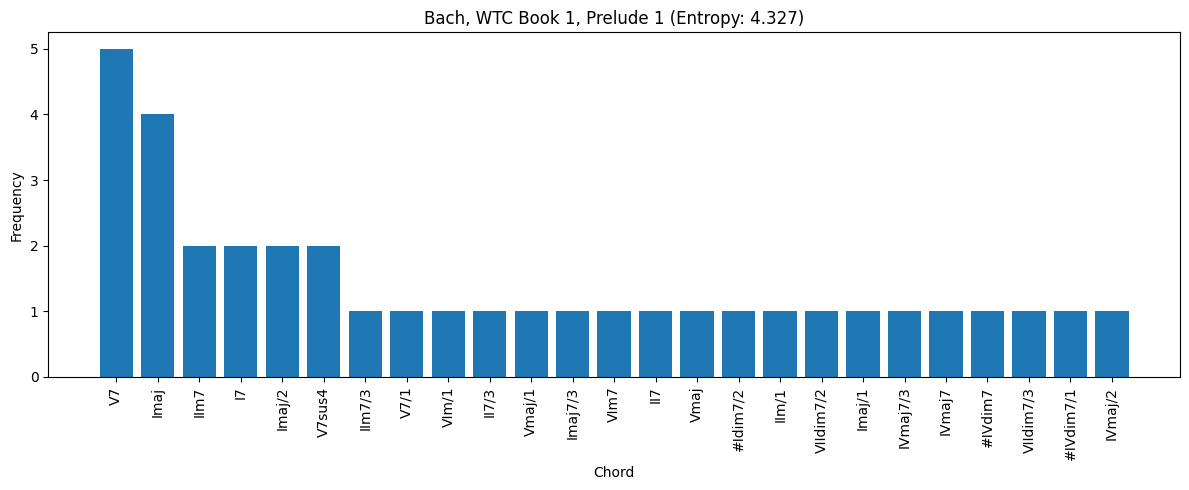

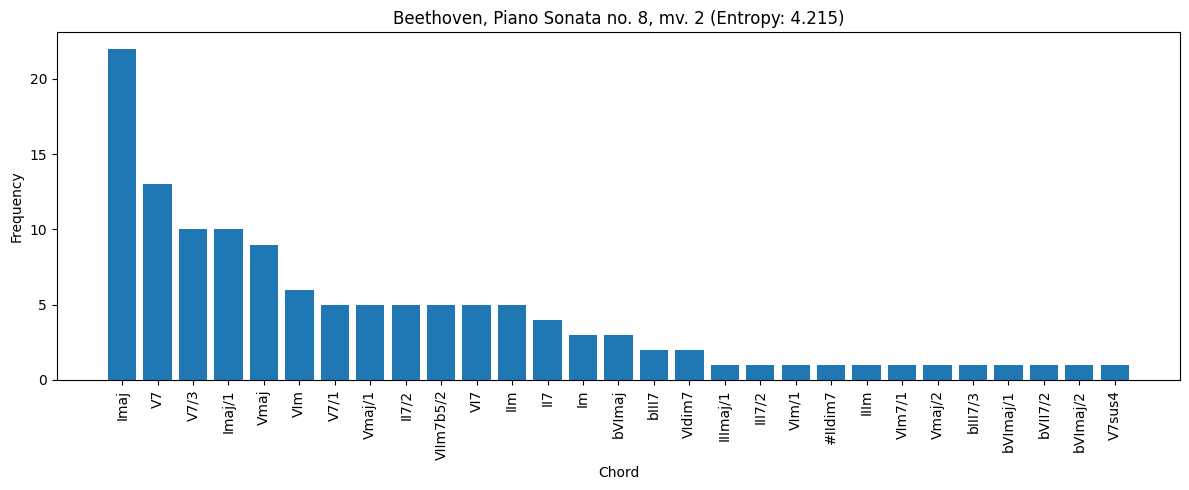

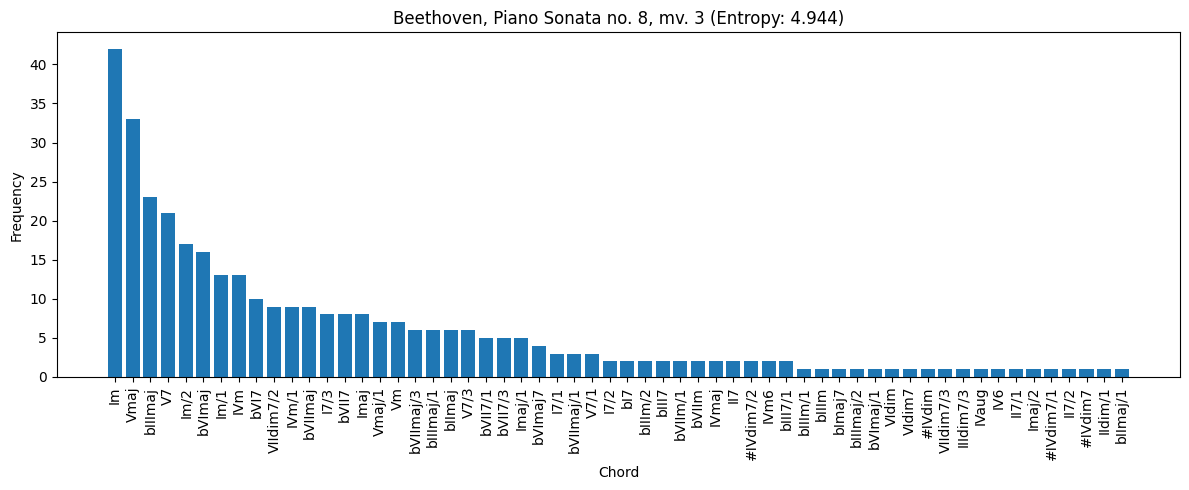

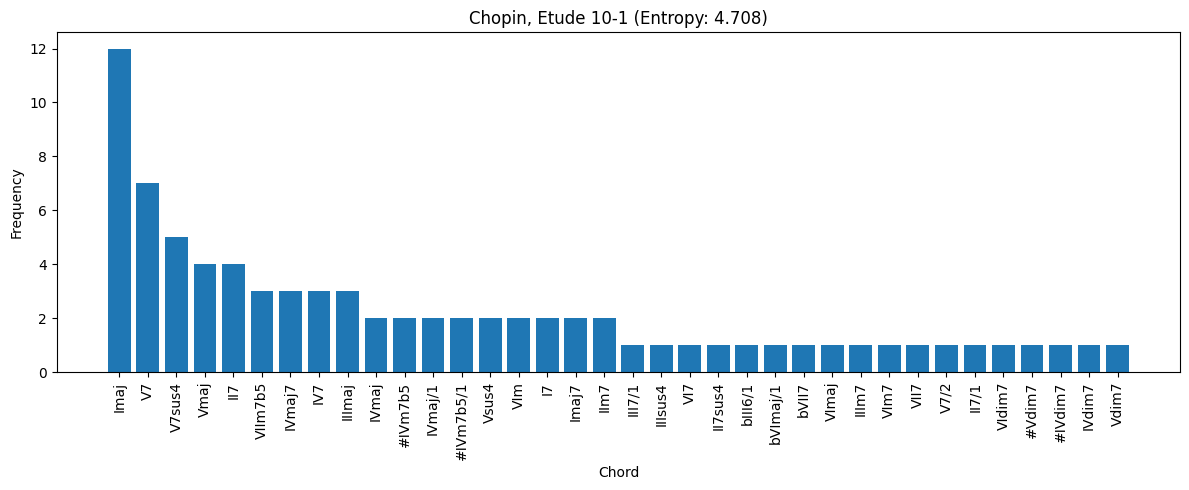

In [4]:
import matplotlib.pyplot as plt

def plot_chord_histogram(chords, title):
	labels = [display_chord(ch) for ch in chords if ch[0] != '.']
	counts = Counter(labels)
	sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
	keys, values = zip(*sorted_items)
	plt.figure(figsize=(12, 5))
	plt.bar(keys, values)
	plt.xticks(rotation=90)
	plt.title(title)
	plt.xlabel('Chord')
	plt.ylabel('Frequency')
	plt.tight_layout()
	plt.show()

plot_chord_histogram(bach_chords, "Bach, WTC Book 1, Prelude 1 (Entropy: {:.3f})".format(bach_entropy))
plot_chord_histogram(beethoven2_chords, "Beethoven, Piano Sonata no. 8, mv. 2 (Entropy: {:.3f})".format(beethoven2_entropy))
plot_chord_histogram(beethoven3_chords, "Beethoven, Piano Sonata no. 8, mv. 3 (Entropy: {:.3f})".format(beethoven3_entropy))
plot_chord_histogram(chopin_chords, "Chopin, Etude 10-1 (Entropy: {:.3f})".format(chopin_entropy))

# Ignore inversions

In [5]:
from collections import Counter
import math

def calculate_entropy(chords):
	counts = Counter(chords)
	total = len(chords)
	entropy = -sum((count/total) * math.log2(count/total) for count in counts.values())
	return entropy

bach_chords = read_chords(os.path.join('bach', 'wtc1-prelude1.txt'), ignore_inversion=True)
beethoven2_chords = read_chords(os.path.join('beethoven', 'sonata08-mv02.txt'), ignore_inversion=True)
beethoven3_chords = read_chords(os.path.join('beethoven', 'sonata08-mv03.txt'), ignore_inversion=True)
chopin_chords = read_chords(os.path.join('chopin', 'etude10-01.txt'), ignore_inversion=True)

bach_entropy = calculate_entropy(bach_chords)
beethoven2_entropy = calculate_entropy(beethoven2_chords)
beethoven3_entropy = calculate_entropy(beethoven3_chords)
chopin_entropy = calculate_entropy(chopin_chords)
#autumnleaves_entropy = calculate_entropy(autumnleaves_chords)
#giantsteps_entropy = calculate_entropy(giantsteps_chords)

print("Bach entropy:", bach_entropy)
print("Beethoven entropy (mov. 2):", beethoven2_entropy)
print("Beethoven entropy (mov. 3):", beethoven3_entropy)
print("Chopin entropy:", chopin_entropy)
#print("Autumn Leaves entropy:", autumnleaves_entropy)
#print("Giant Steps entropy:", giantsteps_entropy)

Bach entropy: 3.7153896055091478
Beethoven entropy (mov. 2): 3.4516258943666873
Beethoven entropy (mov. 3): 4.06965096168944
Chopin entropy: 4.530990186162398


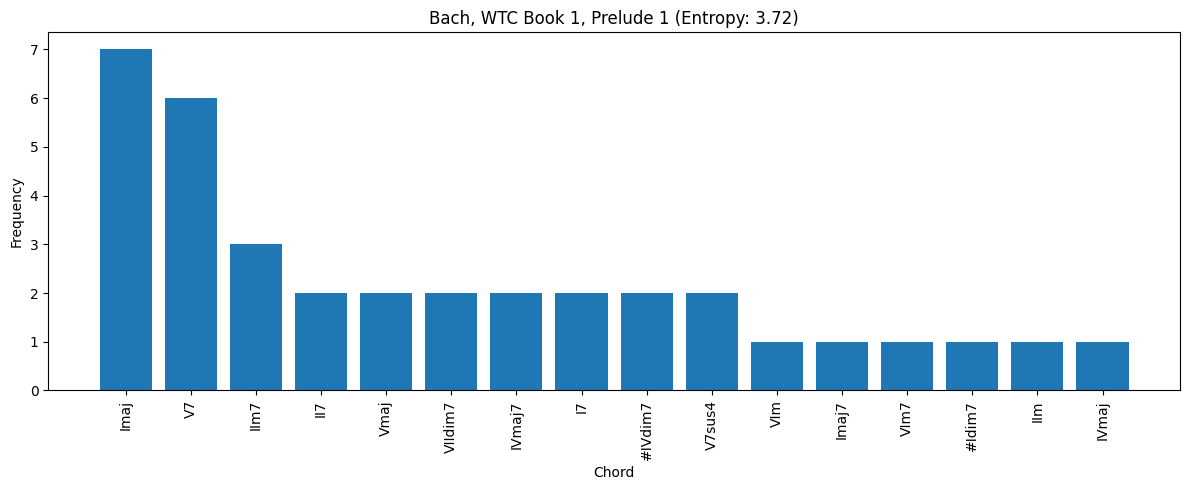

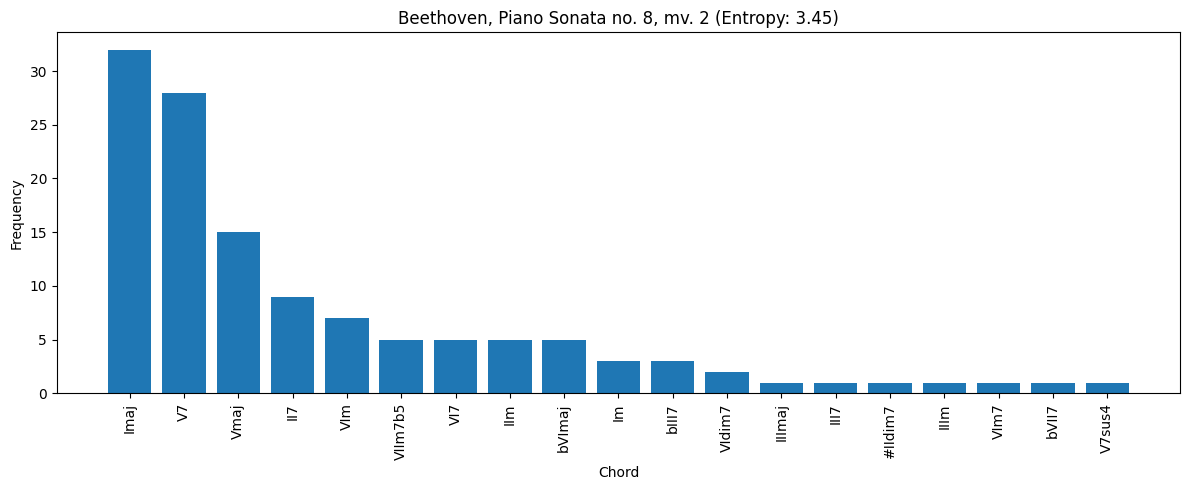

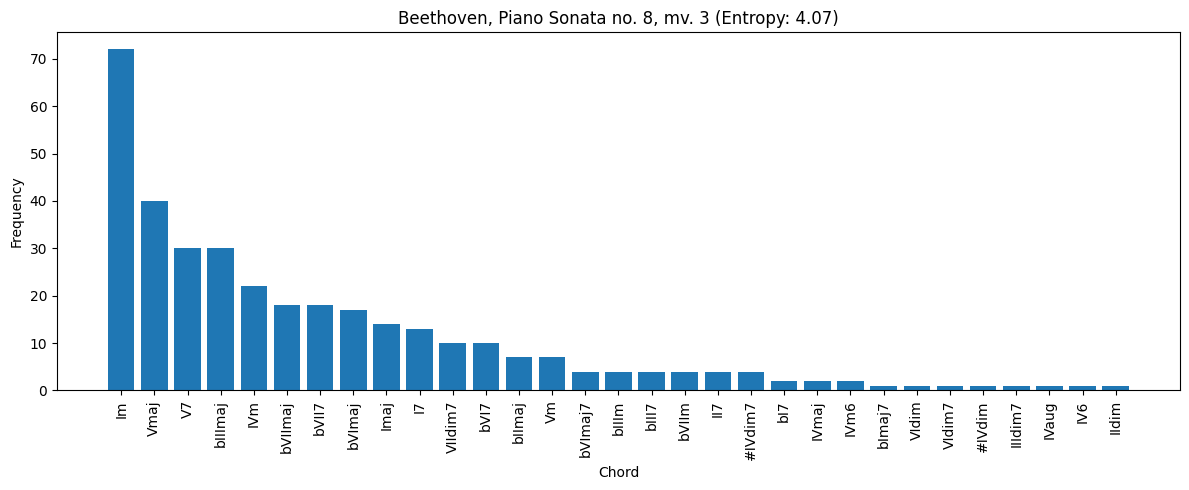

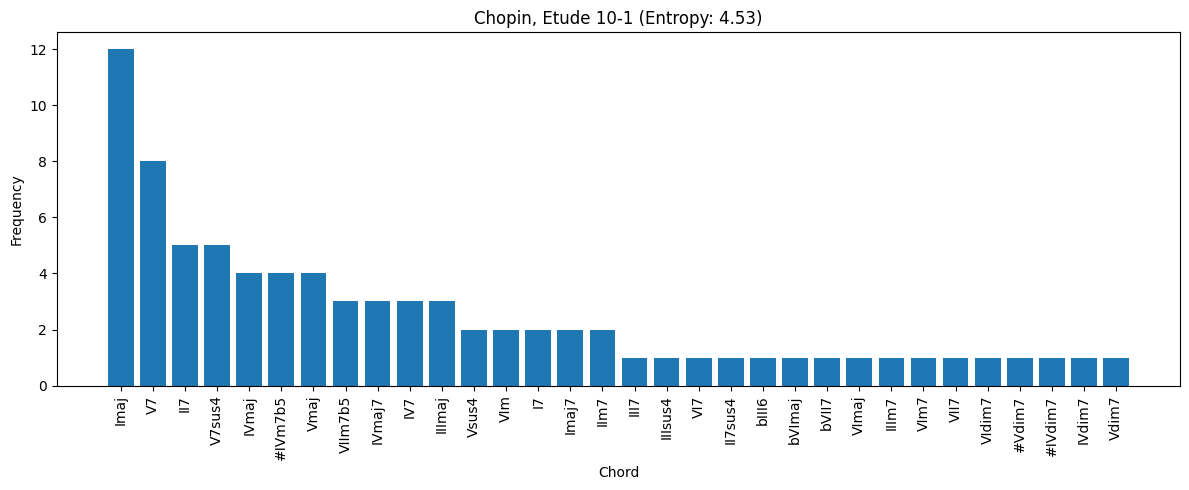

In [6]:
import matplotlib.pyplot as plt

def plot_chord_histogram(chords, title):
	labels = [display_chord(ch) for ch in chords if ch[0] != '.']
	counts = Counter(labels)
	sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
	keys, values = zip(*sorted_items)
	plt.figure(figsize=(12, 5))
	plt.bar(keys, values)
	plt.xticks(rotation=90)
	plt.title(title)
	plt.xlabel('Chord')
	plt.ylabel('Frequency')
	plt.tight_layout()
	plt.show()

plot_chord_histogram(bach_chords, "Bach, WTC Book 1, Prelude 1 (Entropy: {:.2f})".format(bach_entropy))
plot_chord_histogram(beethoven2_chords, "Beethoven, Piano Sonata no. 8, mv. 2 (Entropy: {:.2f})".format(beethoven2_entropy))
plot_chord_histogram(beethoven3_chords, "Beethoven, Piano Sonata no. 8, mv. 3 (Entropy: {:.2f})".format(beethoven3_entropy))
plot_chord_histogram(chopin_chords, "Chopin, Etude 10-1 (Entropy: {:.2f})".format(chopin_entropy))